In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter


In [2]:
df = pd.read_csv("Dataset-SA.csv")

In [3]:
df

,product_name,product_price,Rate,Review,Summary,Sentiment
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,super!,great cooler excellent air flow and for this p...,positive
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,best budget 2 fit cooler nice cooling,positive
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,the quality is good but the power of air is de...,positive
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,useless product,very bad product its a only a fan,negative
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,ok ok product,neutral
...,...,...,...,...,...,...
205047,cello Pack of 18 Opalware Cello Dazzle Lush Fi...,1299,5,must buy!,good product,positive
205048,cello Pack of 18 Opalware Cello Dazzle Lush Fi...,1299,5,super!,nice,positive
205049,cello Pack of 18 Opalware Cello Dazzle Lush Fi...,1299,3,nice,very nice and fast delivery,positive
205050,cello Pack of 18 Opalware Cello Dazzle Lush Fi...,1299,5,just wow!,awesome product,positive


In [4]:
print("\nFIRST 5 RECORDS")
print(df.head())


FIRST 5 RECORDS
                                        product_name product_price Rate  \
0  Candes 12 L Room/Personal Air Cooler??????(Whi...          3999    5   
1  Candes 12 L Room/Personal Air Cooler??????(Whi...          3999    5   
2  Candes 12 L Room/Personal Air Cooler??????(Whi...          3999    3   
3  Candes 12 L Room/Personal Air Cooler??????(Whi...          3999    1   
4  Candes 12 L Room/Personal Air Cooler??????(Whi...          3999    3   

            Review                                            Summary  \
0           super!  great cooler excellent air flow and for this p...   
1          awesome              best budget 2 fit cooler nice cooling   
2             fair  the quality is good but the power of air is de...   
3  useless product                  very bad product its a only a fan   
4             fair                                      ok ok product   

  Sentiment  
0  positive  
1  positive  
2  positive  
3  negative  
4   neutral  


In [5]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205052 entries, 0 to 205051
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   product_name   205052 non-null  object
 1   product_price  205052 non-null  object
 2   Rate           205052 non-null  object
 3   Review         180388 non-null  object
 4   Summary        205041 non-null  object
 5   Sentiment      205052 non-null  object
dtypes: object(6)
memory usage: 9.4+ MB
None


In [6]:
print(df.shape)

(205052, 6)


In [7]:
print(df.columns)

Index(['product_name', 'product_price', 'Rate', 'Review', 'Summary',
       'Sentiment'],
      dtype='object')


In [9]:
df['Rate'] = pd.to_numeric(df['Rate'], errors='coerce')

In [12]:
df.dtypes

product_name      object
product_price     object
Rate             float64
Review            object
Summary           object
Sentiment         object
dtype: object

In [10]:
print(df.isnull().sum())

product_name         0
product_price        0
Rate                 3
Review           24664
Summary             11
Sentiment            0
dtype: int64


In [ ]:
#SENTIMENT DISTRIBUTION

In [13]:
print("\nSENTIMENT COUNTS")

sentiment_counts = df['Sentiment'].value_counts()

print(sentiment_counts)



SENTIMENT COUNTS
Sentiment
positive    166581
negative     28232
neutral      10239
Name: count, dtype: int64


In [ ]:
# AVERAGE RATING BY SENTIMENT

In [14]:
print("\nAVERAGE RATING BY SENTIMENT")

avg_rating = df.groupby('Sentiment')['Rate'].mean()

print(avg_rating)


AVERAGE RATING BY SENTIMENT
Sentiment
negative    1.591655
neutral     3.302178
positive    4.602831
Name: Rate, dtype: float64


In [ ]:
# NLP EMOTION DETECTION USING LEXICON METHOD

In [15]:
emotion_lexicon = {
    "joy": [
        "good", "great", "excellent", "happy",
        "love", "amazing", "awesome", "best"
    ],
    "anger": [
        "bad", "worst", "hate", "angry",
        "poor", "terrible", "waste"
    ],
    "sadness": [
        "sad", "disappointed", "problem",
        "issue", "broken", "damage"
    ],
    "fear": [
        "risk", "unsafe", "danger",
        "scared", "warning"
    ],
    "surprise": [
        "unexpected", "wow",
        "surprised", "shocking"
    ]
}

In [ ]:
# EMOTION DETECTION FUNCTION

In [17]:
def detect_emotions(text):

    # Convert text to lowercase
    text = str(text).lower()

    detected_emotions = []

    # Check words in each emotion category
    for emotion, keywords in emotion_lexicon.items():

        if any(word in text for word in keywords):
            detected_emotions.append(emotion)

    # If no emotion detected
    if len(detected_emotions) == 0:
        return ["neutral"]

    return detected_emotions

In [ ]:
# APPLY EMOTION DETECTION

In [18]:
# Apply function on Review column
df['Emotions'] = df['Review'].apply(detect_emotions)

print("\nEMOTION DETECTION SAMPLE")

print(df[['Review', 'Emotions']].head())


EMOTION DETECTION SAMPLE
            Review   Emotions
0           super!  [neutral]
1          awesome      [joy]
2             fair  [neutral]
3  useless product  [neutral]
4             fair  [neutral]


In [ ]:
# COUNT EMOTIONS

In [19]:

emotion_counter = Counter()

for emotions in df['Emotions']:
    emotion_counter.update(emotions)

emotion_df = pd.DataFrame(
    list(emotion_counter.items()),
    columns=['Emotion', 'Count']
)

emotion_df = emotion_df.sort_values(
    by='Count',
    ascending=False
)

print("\nEMOTION COUNTS")
print(emotion_df)


EMOTION COUNTS
    Emotion   Count
0   neutral  143320
1       joy   45713
3     anger    8354
2  surprise    5536
4   sadness    2145
5      fear       3


In [ ]:
# SENTIMENT DISTRIBUTION

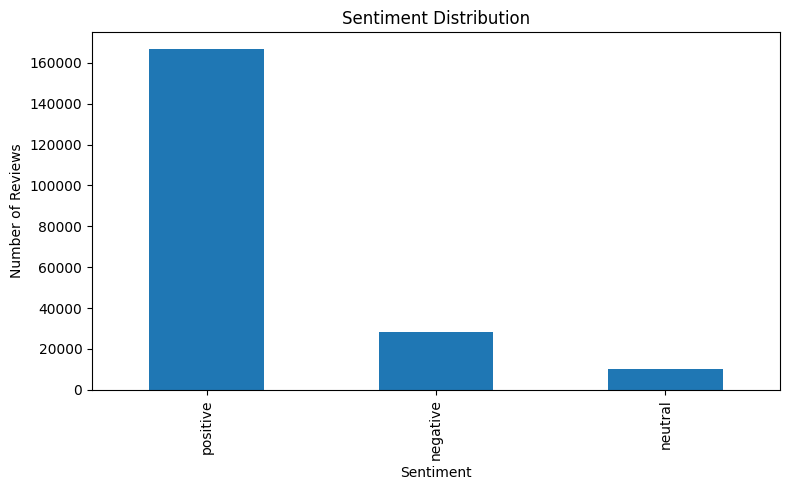

In [20]:
plt.figure(figsize=(8, 5))

sentiment_counts.plot(kind='bar')

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.tight_layout()

plt.show()

In [ ]:
# EMOTION DISTRIBUTION

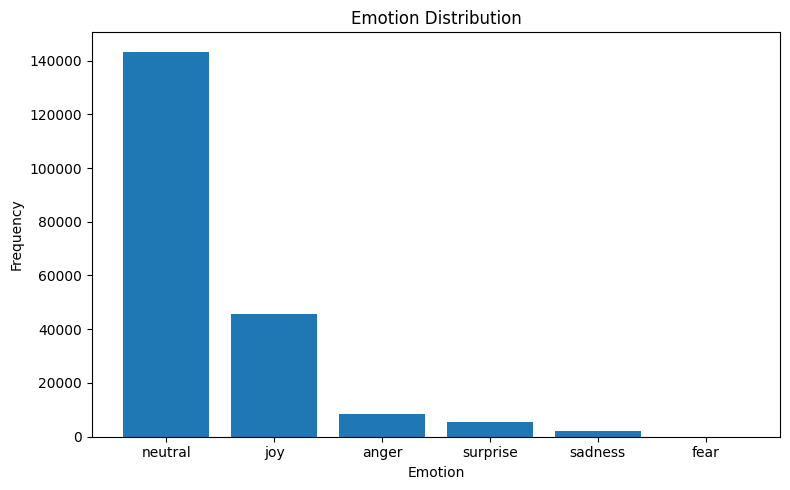

In [21]:
plt.figure(figsize=(8, 5))

plt.bar(
    emotion_df['Emotion'],
    emotion_df['Count']
)

plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Frequency")

plt.tight_layout()

plt.show()


In [22]:
output_file = "sentiment_analysis_results.csv"

df.to_csv(output_file, index=False)

print("\nPROCESSED DATASET SAVED SUCCESSFULLY")


PROCESSED DATASET SAVED SUCCESSFULLY


In [23]:
df

,product_name,product_price,Rate,Review,Summary,Sentiment,Emotions
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5.0,super!,great cooler excellent air flow and for this p...,positive,[neutral]
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5.0,awesome,best budget 2 fit cooler nice cooling,positive,[joy]
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3.0,fair,the quality is good but the power of air is de...,positive,[neutral]
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1.0,useless product,very bad product its a only a fan,negative,[neutral]
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3.0,fair,ok ok product,neutral,[neutral]
...,...,...,...,...,...,...,...
205047,cello Pack of 18 Opalware Cello Dazzle Lush Fi...,1299,5.0,must buy!,good product,positive,[neutral]
205048,cello Pack of 18 Opalware Cello Dazzle Lush Fi...,1299,5.0,super!,nice,positive,[neutral]
205049,cello Pack of 18 Opalware Cello Dazzle Lush Fi...,1299,3.0,nice,very nice and fast delivery,positive,[neutral]
205050,cello Pack of 18 Opalware Cello Dazzle Lush Fi...,1299,5.0,just wow!,awesome product,positive,[surprise]


In [ ]:
# BUSINESS INSIGHTS


1. Positive reviews dominate the dataset, indicating overall customer satisfaction.

2. Negative reviews commonly include anger-related words like:
   'bad', 'worst', 'terrible'.

3. Emotion analysis helps businesses:
   - Understand customer feelings
   - Detect product issues
   - Improve customer service
   - Track public opinion trends

4. Marketing teams can use sentiment trends to improve brand campaigns.

5. Product development teams can identify recurring complaints for future updates.